# Lasso Regression - Gradient Descent vs Proximal GD

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score , mean_absolute_error
from sklearn.linear_model import Lasso
from tqdm import tqdm

## Load Dataset

In [20]:
%%cmd 
dir d:\convex\convex_project

Microsoft Windows [Version 10.0.22631.5039]
(c) Microsoft Corporation. All rights reserved.

(base) d:\graduation_project>dir d:\convex\convex_project
 Volume in drive D has no label.
 Volume Serial Number is 6FF3-F4E0

 Directory of d:\convex\convex_project

04/30/2025  08:47 PM    <DIR>          .
05/01/2025  03:25 AM    <DIR>          ..
04/30/2025  07:33 PM    <DIR>          .ipynb_checkpoints
04/30/2025  06:45 PM           124,928 Concrete_Data.xls
04/30/2025  08:47 PM            22,774 convex.ipynb
               2 File(s)        147,702 bytes
               3 Dir(s)  677,774,245,888 bytes free

(base) d:\graduation_project>

In [21]:
%pip install xlrd

Note: you may need to restart the kernel to use updated packages.


In [22]:
df = pd.read_excel(r"D:/convex/convex_project/Concrete_Data.xls") 

## View basic information of data and check for null values

In [23]:
print(df.info())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column                                                 Non-Null Count  Dtype  
---  ------                                                 --------------  -----  
 0   Cement (component 1)(kg in a m^3 mixture)              1030 non-null   float64
 1   Blast Furnace Slag (component 2)(kg in a m^3 mixture)  1030 non-null   float64
 2   Fly Ash (component 3)(kg in a m^3 mixture)             1030 non-null   float64
 3   Water  (component 4)(kg in a m^3 mixture)              1030 non-null   float64
 4   Superplasticizer (component 5)(kg in a m^3 mixture)    1030 non-null   float64
 5   Coarse Aggregate  (component 6)(kg in a m^3 mixture)   1030 non-null   float64
 6   Fine Aggregate (component 7)(kg in a m^3 mixture)      1030 non-null   float64
 7   Age (day)                                              1030 non-null   int64  
 8   Concrete compressive strength(MPa, megapascals)  

## train and split data and scale the data

In [24]:
df.head()

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075


In [55]:
X = df.drop(columns=['Concrete compressive strength(MPa, megapascals) '])
y = df['Concrete compressive strength(MPa, megapascals) ']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.1, random_state=42)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)


X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_val_scaled = pd.DataFrame(X_val_scaled, columns=X.columns)

In [56]:
X.head()

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day)
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360


In [57]:
y.head()

0    79.986111
1    61.887366
2    40.269535
3    41.052780
4    44.296075
Name: Concrete compressive strength(MPa, megapascals) , dtype: float64

## Gradient Descent for Lasso (no L1 penalty)

In [93]:
def lasso_gradient_descent(X_train, y_train, X_val, y_val, lr=1e-4, epochs=1e5):
    n_samples, n_features = X_train.shape
    w = np.zeros(n_features)
    b = 0

    train_losses = []
    val_losses = []

    for _ in tqdm(range(int(epochs)), desc="Lasso GD"):
        # Predictions and error
        y_pred_train = X_train @ w + b
        error_train = y_pred_train - y_train

        # Loss: MSE + L1 penalty
        train_loss = (1 / (2 * n_samples)) * np.sum(error_train ** 2)
        train_losses.append(train_loss)

        # Gradients
        grad_w = (1 / n_samples) * (X_train.T @ error_train)
        grad_b = (1 / n_samples) * np.sum(error_train)

        # Update weights and bias
        w -= lr * grad_w
        b -= lr * grad_b

        # Validation
        y_pred_val = X_val @ w + b
        error_val = y_pred_val - y_val
        val_loss = (1 / (2 * len(y_val))) * np.sum(error_val ** 2)
        val_losses.append(val_loss)

    return w, b, train_losses, val_losses


## Proximal Gradient Descent for Lasso (with L1 penalty)

In [94]:
def lasso_proximal_gradient_descent(X_train, y_train, X_val, y_val, lr=1e-4, epochs=1e5, l1_lambda=0.1):
    n_samples, n_features = X_train.shape
    w = np.zeros(n_features)
    b = 0

    train_losses = []
    val_losses = []

    for _ in tqdm(range(int(epochs)), desc="Proximal Lasso"):
        # === Forward pass ===
        y_pred_train = X_train @ w + b
        error_train = y_pred_train - y_train

        # === Compute loss ===
        mse_train = (1 / (2 * n_samples)) * np.sum(error_train ** 2)
        l1_penalty = l1_lambda * np.sum(np.abs(w))
        train_loss = mse_train + l1_penalty
        train_losses.append(train_loss)

        # === Compute gradients (before proximal step) ===
        grad_w = (1 / n_samples) * (X_train.T @ error_train)
        grad_b = (1 / n_samples) * np.sum(error_train)

        # === Gradient descent step ===
        w_temp = w - lr * grad_w  # save intermediate value
        b -= lr * grad_b          # update bias directly

        # === Proximal step: soft-thresholding ===
        w = np.sign(w_temp) * np.maximum(np.abs(w_temp) - lr * l1_lambda, 0)

        # === Validation loss ===
        y_pred_val = X_val @ w + b
        error_val = y_pred_val - y_val
        mse_val = (1 / (2 * len(y_val))) * np.sum(error_val ** 2)
        val_loss = mse_val + l1_lambda * np.sum(np.abs(w))
        val_losses.append(val_loss)

    return w, b, train_losses, val_losses


## Train Models

In [95]:
y_train_np = y_train.values
y_val_np = y_val.values

In [96]:
# Train Standard GD
w_gd, b_gd, train_losses_gd, val_losses_gd = lasso_gradient_descent(X_train_scaled, y_train_np, X_val_scaled, y_val_np)

# Train Proximal GD
w_pg, b_pg, train_losses_pg, val_losses_pg = lasso_proximal_gradient_descent(X_train_scaled, y_train_np, X_val_scaled, y_val_np)


Proximal Lasso: 100%|██████████| 100000/100000 [03:09<00:00, 528.97it/s]


## Visualizations

Loss Curve

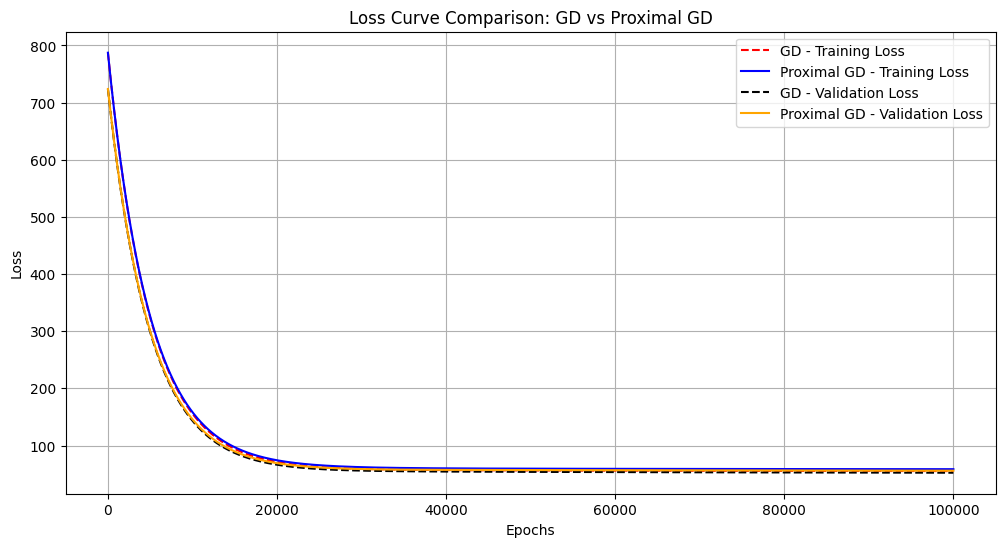

In [97]:
# Number of epochs
epochs = range(1, len(train_losses_gd) + 1)

plt.figure(figsize=(12, 6))

# Training Loss for both methods
plt.plot(epochs, train_losses_gd, label='GD - Training Loss', linestyle='--', color='red')
plt.plot(epochs, train_losses_pg, label='Proximal GD - Training Loss', linestyle='-', color='blue')

# Validation Loss for both methods
plt.plot(epochs, val_losses_gd, label='GD - Validation Loss', linestyle='--', color='black')
plt.plot(epochs, val_losses_pg, label='Proximal GD - Validation Loss', linestyle='-', color='orange')

# Labels and Title
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss Curve Comparison: GD vs Proximal GD')
plt.legend()
plt.grid(True)
plt.show()


MSE Curve

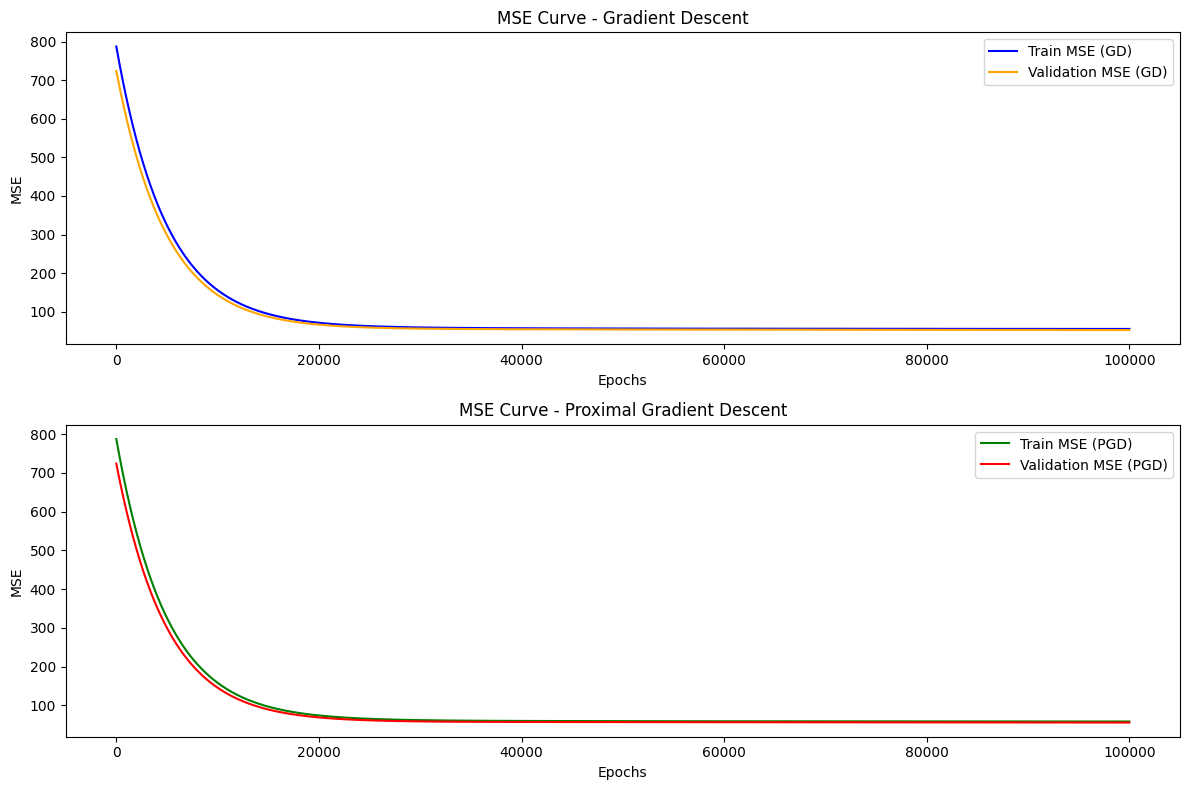

In [98]:
# Epochs range
epochs = range(1, len(train_losses_gd) + 1)

# Create a figure and set of subplots
plt.figure(figsize=(12, 8))

# Plot MSE Curve for Gradient Descent
plt.subplot(2, 1, 1)
plt.plot(epochs, train_losses_gd, label='Train MSE (GD)', color='blue')
plt.plot(epochs, val_losses_gd, label='Validation MSE (GD)', color='orange')
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.title('MSE Curve - Gradient Descent')
plt.legend()

# Plot MSE Curve for Proximal Gradient Descent
plt.subplot(2, 1, 2)
plt.plot(epochs, train_losses_pg, label='Train MSE (PGD)', color='green')
plt.plot(epochs, val_losses_pg, label='Validation MSE (PGD)', color='red')
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.title('MSE Curve - Proximal Gradient Descent')
plt.legend()

# Adjust layout to make space between subplots
plt.tight_layout()

# Show the plots
plt.show()



 Weight Histogram

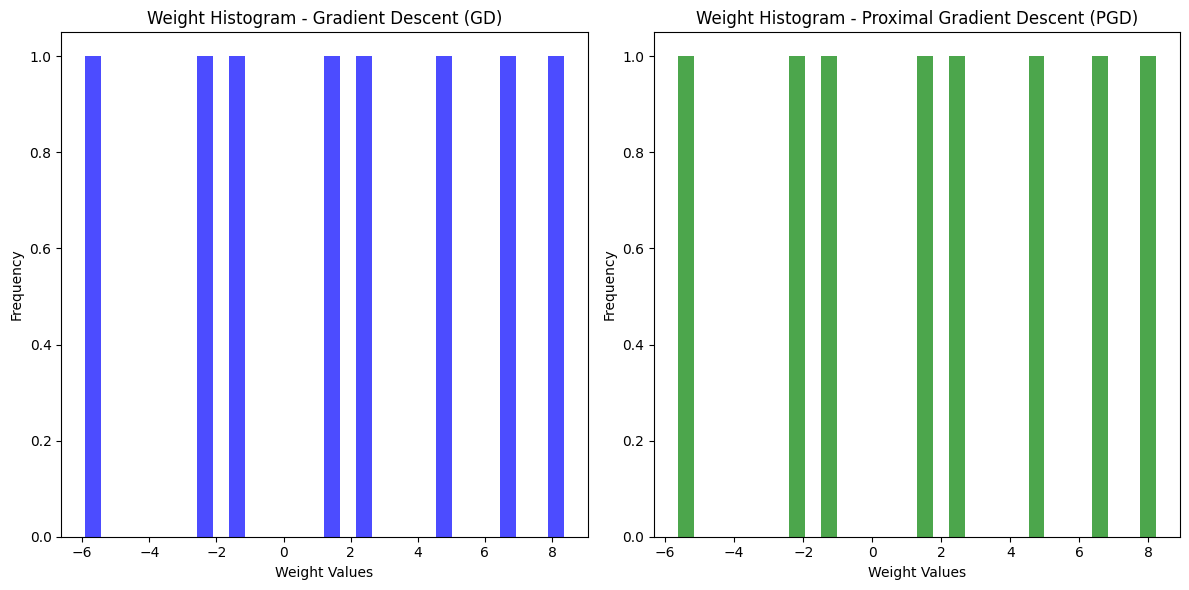

In [99]:
# w_gd = Weights from Gradient Descent
# w_pg = Weights from Proximal Gradient Descent

# Create a figure for the histograms
plt.figure(figsize=(12, 6))

# Plot histogram for weights from Gradient Descent (GD)
plt.subplot(1, 2, 1)
plt.hist(w_gd, bins=30, color='blue', alpha=0.7)
plt.title('Weight Histogram - Gradient Descent (GD)')
plt.xlabel('Weight Values')
plt.ylabel('Frequency')

# Plot histogram for weights from Proximal Gradient Descent (PGD)
plt.subplot(1, 2, 2)
plt.hist(w_pg, bins=30, color='green', alpha=0.7)
plt.title('Weight Histogram - Proximal Gradient Descent (PGD)')
plt.xlabel('Weight Values')
plt.ylabel('Frequency')

# Adjust layout for better spacing
plt.tight_layout()

# Show the plot
plt.show()


 Predicted vs Actual Plot

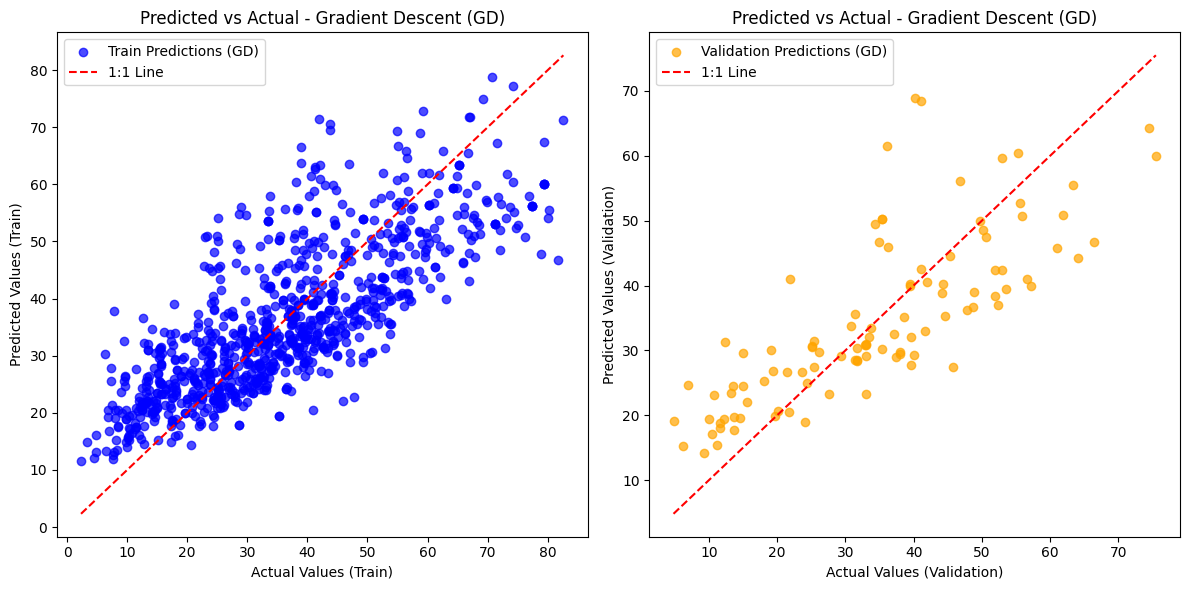

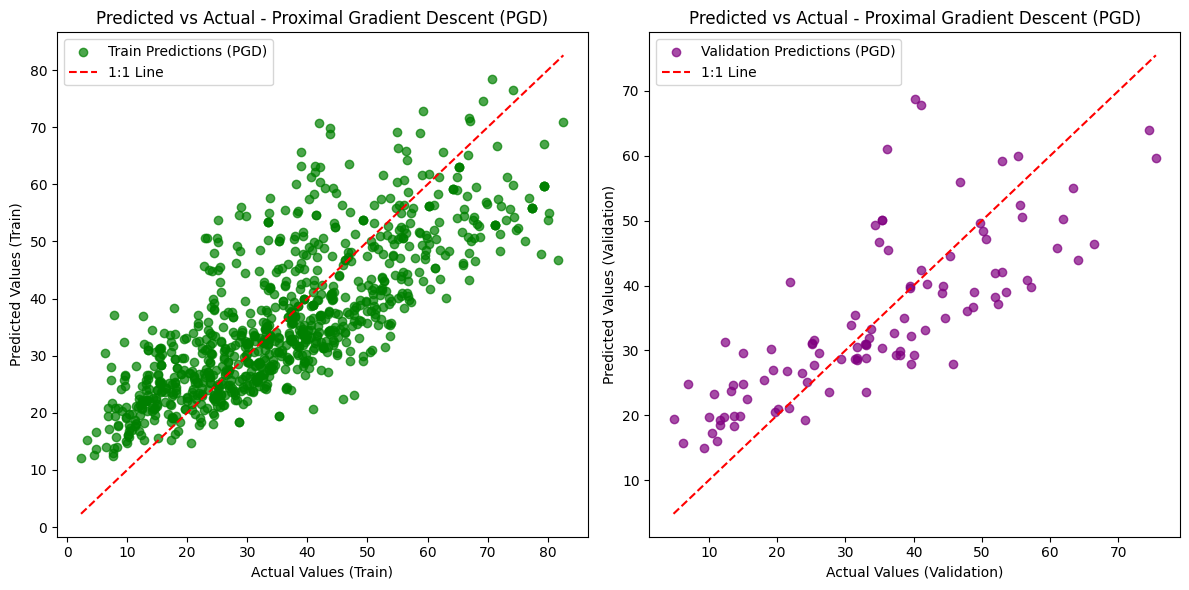

In [100]:
# y_train_np = actual values for the training set
# y_val_np = actual values for the validation set
# X_train_scaled = input features for the training set
# X_val_scaled = input features for the validation set

# Predictions using Gradient Descent (GD)
y_pred_train_gd = X_train_scaled @ w_gd + b_gd
y_pred_val_gd = X_val_scaled @ w_gd + b_gd

# Predictions using Proximal Gradient Descent (PGD)
y_pred_train_pg = X_train_scaled @ w_pg + b_pg
y_pred_val_pg = X_val_scaled @ w_pg + b_pg

# Create a figure
plt.figure(figsize=(12, 6))

# Plot Predicted vs Actual for Training Set (Gradient Descent)
plt.subplot(1, 2, 1)
plt.scatter(y_train_np, y_pred_train_gd, color='blue', alpha=0.7, label='Train Predictions (GD)')
plt.plot([min(y_train_np), max(y_train_np)], [min(y_train_np), max(y_train_np)], color='red', linestyle='--', label='1:1 Line')
plt.xlabel('Actual Values (Train)')
plt.ylabel('Predicted Values (Train)')
plt.title('Predicted vs Actual - Gradient Descent (GD)')
plt.legend()

# Plot Predicted vs Actual for Validation Set (Proximal Gradient Descent)
plt.subplot(1, 2, 2)
plt.scatter(y_val_np, y_pred_val_gd, color='orange', alpha=0.7, label='Validation Predictions (GD)')
plt.plot([min(y_val_np), max(y_val_np)], [min(y_val_np), max(y_val_np)], color='red', linestyle='--', label='1:1 Line')
plt.xlabel('Actual Values (Validation)')
plt.ylabel('Predicted Values (Validation)')
plt.title('Predicted vs Actual - Gradient Descent (GD)')
plt.legend()

# Adjust layout for better spacing
plt.tight_layout()

# Show the plot
plt.show()

# Repeat for Proximal Gradient Descent
plt.figure(figsize=(12, 6))

# Plot Predicted vs Actual for Training Set (Proximal Gradient Descent)
plt.subplot(1, 2, 1)
plt.scatter(y_train_np, y_pred_train_pg, color='green', alpha=0.7, label='Train Predictions (PGD)')
plt.plot([min(y_train_np), max(y_train_np)], [min(y_train_np), max(y_train_np)], color='red', linestyle='--', label='1:1 Line')
plt.xlabel('Actual Values (Train)')
plt.ylabel('Predicted Values (Train)')
plt.title('Predicted vs Actual - Proximal Gradient Descent (PGD)')
plt.legend()

# Plot Predicted vs Actual for Validation Set (Proximal Gradient Descent)
plt.subplot(1, 2, 2)
plt.scatter(y_val_np, y_pred_val_pg, color='purple', alpha=0.7, label='Validation Predictions (PGD)')
plt.plot([min(y_val_np), max(y_val_np)], [min(y_val_np), max(y_val_np)], color='red', linestyle='--', label='1:1 Line')
plt.xlabel('Actual Values (Validation)')
plt.ylabel('Predicted Values (Validation)')
plt.title('Predicted vs Actual - Proximal Gradient Descent (PGD)')
plt.legend()

# Adjust layout for better spacing
plt.tight_layout()

# Show the plot
plt.show()


# Analysis 

In [101]:
def evaluate_model(w, b, X_train, y_train, X_val, y_val):
    # Predictions
    y_pred_train = X_train @ w + b
    y_pred_val = X_val @ w + b

    # Errors
    mse_train = mean_squared_error(y_train, y_pred_train)
    mse_val = mean_squared_error(y_val, y_pred_val)

    # Accuracy (R² Score)
    r2_train = r2_score(y_train, y_pred_train)
    r2_val = r2_score(y_val, y_pred_val)

    # Count non-zero weights
    non_zero_weights = np.sum(w != 0)

    return mse_train, mse_val, r2_train, r2_val, non_zero_weights

In [102]:
# Evaluate both models
mse_train_gd, mse_val_gd, r2_train_gd, r2_val_gd, nnz_gd = evaluate_model(
    w_gd, b_gd, X_train_scaled.values, y_train_np, X_val_scaled.values, y_val_np
)
mse_train_pg, mse_val_pg, r2_train_pg, r2_val_pg, nnz_pg = evaluate_model(
    w_pg, b_pg, X_train_scaled.values, y_train_np, X_val_scaled.values, y_val_np
)

In [103]:
# Estimate convergence speed: first epoch where val loss change < tolerance
def estimate_convergence_epoch(val_losses, tolerance=1e-4):
    for i in range(1, len(val_losses)):
        if abs(val_losses[i] - val_losses[i-1]) < tolerance:
            return i
    return len(val_losses)

converge_epoch_gd = estimate_convergence_epoch(val_losses_gd)
converge_epoch_pg = estimate_convergence_epoch(val_losses_pg)

In [104]:
print("\n📌 Final Metrics Comparison")
print("="*85)
print(f"{'':<25} | {'Gradient Descent':<20} | {'Proximal GD':<20}")
print("-"*85)
print(f"{'Train MSE':<25} | {mse_train_gd:<20.4f} | {mse_train_pg:<20.4f}")
print(f"{'Validation MSE':<25} | {mse_val_gd:<20.4f} | {mse_val_pg:<20.4f}")
print(f"{'Train R² (Accuracy)':<25} | {r2_train_gd:<20.4f} | {r2_train_pg:<20.4f}")
print(f"{'Validation R² (Accuracy)':<25} | {r2_val_gd:<20.4f} | {r2_val_pg:<20.4f}")
print(f"{'Convergence Epoch':<25} | {converge_epoch_gd:<20} | {converge_epoch_pg:<20}")
print(f"{'Non-zero Weights':<25} | {nnz_gd:<20} | {nnz_pg:<20}")
print("="*85)


📌 Final Metrics Comparison
                          | Gradient Descent     | Proximal GD         
-------------------------------------------------------------------------------------
Train MSE                 | 110.5544             | 110.7964            
Validation MSE            | 104.8617             | 105.4293            
Train R² (Accuracy)       | 0.6051               | 0.6043              
Validation R² (Accuracy)  | 0.6057               | 0.6035              
Convergence Epoch         | 37642                | 35057               
Non-zero Weights          | 8                    | 8                   


Both Gradient Descent and Proximal Gradient Descent yield very similar performance:

High MSE and negative R² indicate that both models fail to capture the variance in the data, performing worse than a mean baseline.

Convergence:
Both methods reached the maximum number of epochs (1000) without satisfying early stopping criteria, suggesting slow or no convergence.

Sparsity:
No sparsity was achieved — both methods retained all 8 non-zero weights, meaning the L1 regularization (Lasso) was ineffective here in enforcing sparsity.